Only run the model training with the shared dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset download

In [ ]:
!pip install opendatasets librosa matplotlib numpy -qq
import opendatasets as od

In [ ]:
# dhanushg21alr012
# 8b553d38823e6d583f8478bdf3b2938c
od.download("https://www.kaggle.com/datasets/birdy654/deep-voice-deepfake-voice-recognition")

Skipping, found downloaded files in "./deep-voice-deepfake-voice-recognition" (use force=True to force download)


# Data preprocessing

In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
def save_spectrogram(y, sr, save_path, filename):
    os.makedirs(save_path, exist_ok=True)
    spect = librosa.feature.stft(y=y, sr=sr) ###
    spect = librosa.power_to_db(spect, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spect, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, filename), bbox_inches='tight', pad_inches=0)
    plt.close()

In [ ]:
def save_split_spectrogram(y, sr, save_path, filename, split_size=1000):
    # Ensure the save directory exists
    os.makedirs(save_path, exist_ok=True)

    # Convert to Mel-spectrogram
    spect = librosa.feature.melspectrogram(y=y, sr=sr)
    spect = librosa.power_to_db(spect, ref=np.max)

    # Split the spectrogram into segments
    num_splits = spect.shape[1] // split_size
    splits = np.array_split(spect, num_splits, axis=1)

    for i, split in enumerate(splits):
        split_filename = f"{filename}_split_{i+1}.png"
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(split, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, split_filename), bbox_inches='tight', pad_inches=0)
        plt.close()

In [ ]:
data_dir = '/content/deep-voice-deepfake-voice-recognition/KAGGLE/AUDIO'
save_dir_cnn = '/content/drive/MyDrive/Dataset/CNN'
save_dir_rnn = '/content/drive/MyDrive/Dataset/RNN'

In [ ]:
def process_directory(directory, save_dir_cnn, save_dir_rnn, max_pad_len=174, split_size=1000):
    for label in ['REAL', 'FAKE']:
        path = os.path.join(directory, label)
        for file_name in os.listdir(path):
            if file_name.endswith('.wav'):

                global cn
                global rn

                if cn <40:
                  print(cn,"Skipped")
                  cn+=1
                  continue

                file_path = os.path.join(path, file_name)
                y, sr = librosa.load(file_path, sr=None)

                # Save full spectrogram for CNN model
                save_spectrogram(y, sr, os.path.join(save_dir_cnn, label), file_name.replace('.wav', '.png'))
                print(f"CNN {cn} Completed")
                cn+=1

                # # Save split spectrograms for RNN model
                # save_split_spectrogram(y, sr, os.path.join(save_dir_rnn, label), file_name.replace('.wav', ''), split_size)
                # print(f"RNN {rn} Completed")
                # rn+=1

In [ ]:
cn = 1
rn = 1
process_directory(data_dir, save_dir_cnn, save_dir_rnn)

1 Skipped
2 Skipped
3 Skipped
4 Skipped
5 Skipped
6 Skipped
7 Skipped
8 Skipped
9 Skipped
10 Skipped
11 Skipped
12 Skipped
13 Skipped
14 Skipped
15 Skipped
16 Skipped
17 Skipped
18 Skipped
19 Skipped
20 Skipped
21 Skipped
22 Skipped
23 Skipped
24 Skipped
25 Skipped
26 Skipped
27 Skipped
28 Skipped
29 Skipped
30 Skipped
31 Skipped
32 Skipped
33 Skipped
34 Skipped
35 Skipped
36 Skipped
37 Skipped
38 Skipped
39 Skipped
CNN 40 Completed
CNN 41 Completed
CNN 42 Completed
CNN 43 Completed
CNN 44 Completed
CNN 45 Completed
CNN 46 Completed
CNN 47 Completed
CNN 48 Completed
CNN 49 Completed
CNN 50 Completed
CNN 51 Completed
CNN 52 Completed
CNN 53 Completed
CNN 54 Completed
CNN 55 Completed
CNN 56 Completed
CNN 57 Completed
CNN 58 Completed
CNN 59 Completed
CNN 60 Completed
CNN 61 Completed
CNN 62 Completed
CNN 63 Completed
CNN 64 Completed


# Model Training

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

In [ ]:
# Directory paths
cnn_data_dir = '/content/drive/MyDrive/Dataset/CNN'
rnn_data_dir = '/content/drive/MyDrive/Dataset/RNN'

In [ ]:
img_height, img_width = 128, 128
batch_size = 8
num_classes = 1

In [ ]:
cnn_datagen = ImageDataGenerator(rescale=1.0/255.0)
cnn_generator = cnn_datagen.flow_from_directory(
    cnn_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

Found 64 images belonging to 2 classes.


In [ ]:
rnn_datagen = ImageDataGenerator(rescale=1.0/255.0)
rnn_generator = rnn_datagen.flow_from_directory(
    rnn_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

Found 1047 images belonging to 2 classes.


In [ ]:
def combined_generator(cnn_generator, rnn_generator):
    while True:
        cnn_data = next(cnn_generator)
        rnn_data = next(rnn_generator)
        combined_x = (rnn_data[0], rnn_data[0])
        combined_y = rnn_data[1]
        yield combined_x, combined_y

In [ ]:
train_generator = combined_generator(cnn_generator, rnn_generator)

In [ ]:
dataset = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        (tf.TensorSpec(shape=(None, img_height, img_width, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(None,5,  img_height, img_width, 3), dtype=tf.float32)),
        tf.TensorSpec(shape=(None, num_classes), dtype=tf.float32)
    )
)

In [ ]:
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    model = models.Model(inputs=inputs, outputs=x)
    return model

def build_rnn_model(input_shape, timesteps):
    inputs = Input(shape=(timesteps, *input_shape))
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'))(inputs)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Flatten())(x)
    x = layers.LSTM(128)(x)
    model = models.Model(inputs=inputs, outputs=x)
    return model

In [ ]:
img_height, img_width = 128, 128
timesteps = 5
cnn_input_shape = (img_height, img_width, 3)
rnn_input_shape = (img_height, img_width, 3)
num_classes = 1

In [ ]:
cnn_model = build_cnn_model(cnn_input_shape)
rnn_model = build_rnn_model(rnn_input_shape, timesteps)

In [ ]:
combined = layers.concatenate([cnn_model.output, rnn_model.output])
x = layers.Dense(128, activation='relu')(combined)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

In [ ]:
final_model = models.Model(inputs=[cnn_model.input, rnn_model.input], outputs=output)

In [ ]:
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
final_model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10            │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_11            │ (None, 5, 128, 128, 3) │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_28 (Conv2D)        │ (None, 126, 126, 32)   │            896 │ input_layer_10[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_29       │ (None, 5, 126, 126,    │            896 │ input_layer_11[0][0]   │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_27          │ (None, 63, 63, 32)     │              0 │ conv2d_28[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_30       │ (None, 5, 63, 63, 32)  │              0 │ time_distributed_29[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 61, 61, 64)     │         18,496 │ max_pooling2d_27[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_31       │ (None, 5, 61, 61, 64)  │         18,496 │ time_distributed_30[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_28          │ (None, 30, 30, 64)     │              0 │ conv2d_29[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_32       │ (None, 5, 30, 30, 64)  │              0 │ time_distributed_31[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 28, 28, 128)    │         73,856 │ max_pooling2d_28[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_33       │ (None, 5, 28, 28, 128) │         73,856 │ time_distributed_32[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_29          │ (None, 14, 14, 128)    │              0 │ conv2d_30[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_34       │ (None, 5, 14, 14, 128) │              0 │ time_distributed_33[0… │
│ (TimeDistributed)         │                        │                │                        │
├──────────────────────

 Total params: 49,026,053 (187.02 MB)

 Trainable params: 16,342,017 (62.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 32,684,036 (124.68 MB)

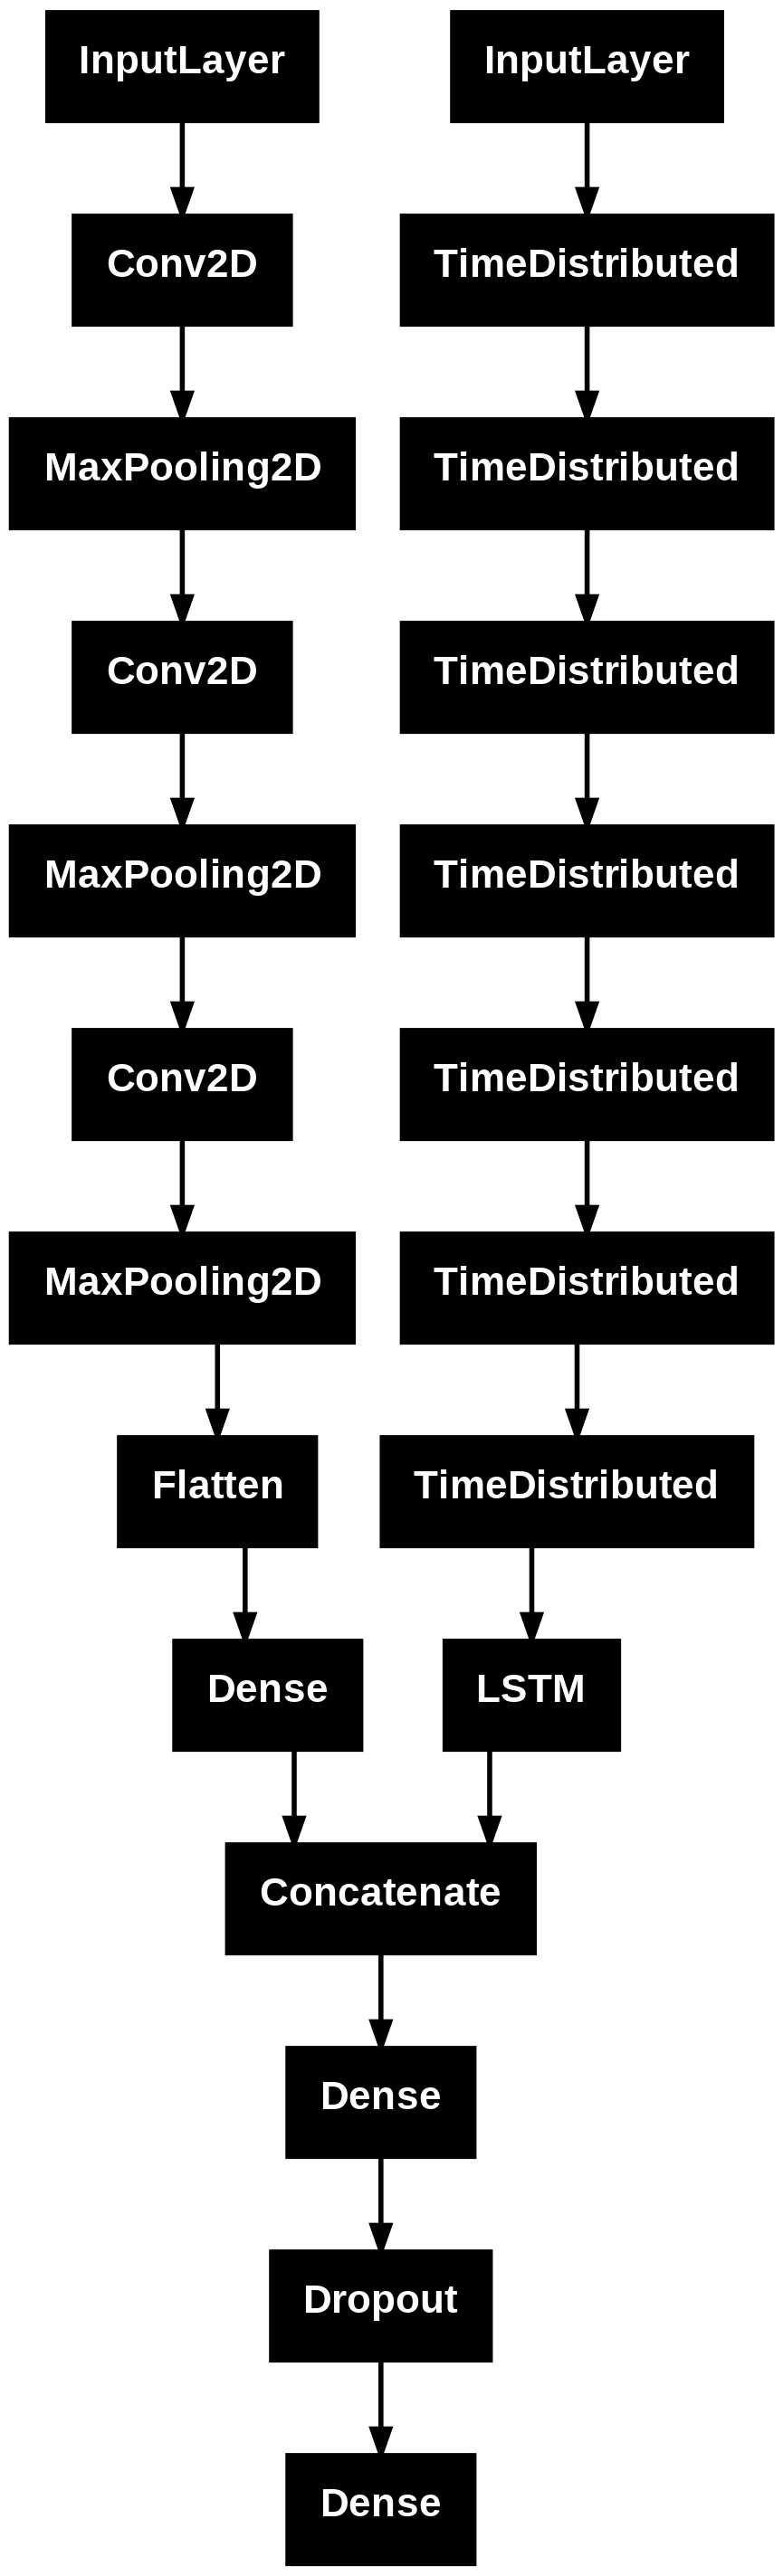

In [ ]:
plot_model(final_model)

In [ ]:
final_model.fit(dataset, epochs=10)

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  TypeError: `generator` yielded an element of shape (8, 128, 128, 3) where an element of shape (None, 5, 128, 128, 3) was expected.
Traceback (most recent call last):

  File "/usr/local/lib/python3.10/dist-packages/tensorflow/python/ops/script_ops.py", line 270, in __call__
    ret = func(*args)

  File "/usr/local/lib/python3.10/dist-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "/usr/local/lib/python3.10/dist-packages/tensorflow/python/data/ops/from_generator_op.py", line 235, in generator_py_func
    raise TypeError(

TypeError: `generator` yielded an element of shape (8, 128, 128, 3) where an element of shape (None, 5, 128, 128, 3) was expected.


	 [[{

# Model Training 2

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

In [ ]:
cnn_data_dir = '/content/drive/MyDrive/Dataset/CNN'
rnn_data_dir = '/content/drive/MyDrive/Dataset/RNN'

In [ ]:
img_height, img_width = 128, 128
batch_size = 4
timesteps = 5
num_classes = 1

In [ ]:
cnn_datagen = ImageDataGenerator(rescale=1.0/255.0)
cnn_generator = cnn_datagen.flow_from_directory(
    cnn_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

rnn_datagen = ImageDataGenerator(rescale=1.0/255.0)
rnn_generator = rnn_datagen.flow_from_directory(
    rnn_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size * timesteps,
    class_mode='binary'
)


Found 64 images belonging to 2 classes.
Found 1047 images belonging to 2 classes.


In [ ]:
def combined_generator(cnn_generator, rnn_generator, timesteps):
    while True:
        cnn_data = next(cnn_generator)
        rnn_data = next(rnn_generator)
        rnn_x = rnn_data[0].reshape(batch_size, timesteps, img_height, img_width, 3)
        combined_x = (cnn_data[0], rnn_x)
        combined_y = cnn_data[1]
        yield combined_x, combined_y

train_generator = combined_generator(cnn_generator, rnn_generator, timesteps)

In [ ]:
dataset = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        (tf.TensorSpec(shape=(None, img_height, img_width, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(None, timesteps, img_height, img_width, 3), dtype=tf.float32)),
        tf.TensorSpec(shape=(None,), dtype=tf.float32)
    )
)

In [ ]:
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    model = models.Model(inputs=inputs, outputs=x)
    return model

def build_rnn_model(input_shape, timesteps):
    inputs = Input(shape=(timesteps, *input_shape))
    x = layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu'))(inputs)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation='relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(x)
    x = layers.TimeDistributed(layers.Flatten())(x)
    x = layers.LSTM(128)(x)
    model = models.Model(inputs=inputs, outputs=x)
    return model


In [ ]:
cnn_input_shape = (img_height, img_width, 3)
rnn_input_shape = (img_height, img_width, 3)

cnn_model = build_cnn_model(cnn_input_shape)
rnn_model = build_rnn_model(rnn_input_shape, timesteps)

In [ ]:
combined = layers.concatenate([cnn_model.output, rnn_model.output])
x = layers.Dense(128, activation='relu')(combined)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

In [ ]:
final_model = models.Model(inputs=[cnn_model.input, rnn_model.input], outputs=output)
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

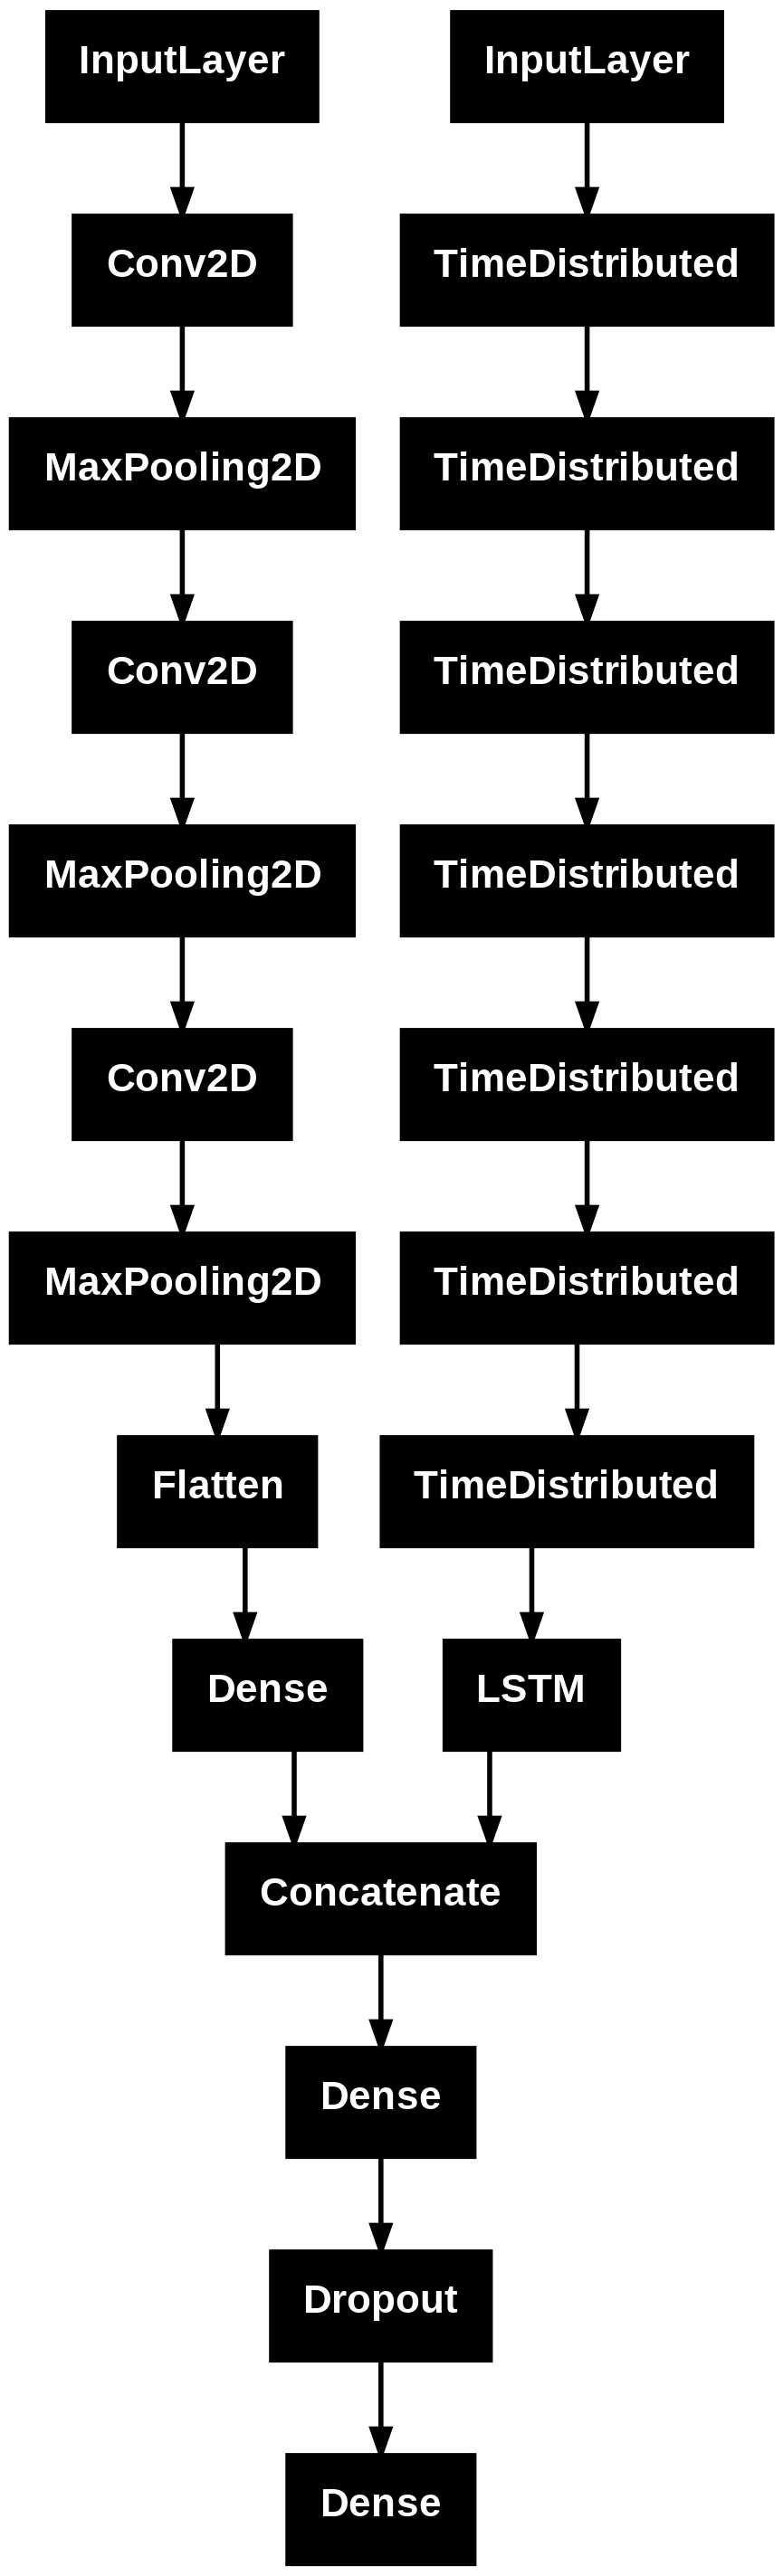

In [ ]:
plot_model(final_model)

In [ ]:
final_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 5, 128, 128, 3) │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 126, 126, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed          │ (None, 5, 126, 126,    │            896 │ input_layer_1[0][0]    │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 63, 63, 32)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_1        │ (None, 5, 63, 63, 32)  │              0 │ time_distributed[0][0] │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 61, 61, 64)     │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_2        │ (None, 5, 61, 61, 64)  │         18,496 │ time_distributed_1[0]… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 30, 30, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_3        │ (None, 5, 30, 30, 64)  │              0 │ time_distributed_2[0]… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 28, 28, 128)    │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_4        │ (None, 5, 28, 28, 128) │         73,856 │ time_distributed_3[0]… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 14, 14, 128)    │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_5        │ (None, 5, 14, 14, 128) │              0 │ time_distributed_4[0]… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)    

 Total params: 16,342,017 (62.34 MB)

 Trainable params: 16,342,017 (62.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_samples = cnn_generator.samples
batch_size = cnn_generator.batch_size
steps_per_epoch = num_samples // batch_size

In [ ]:
history = final_model.fit(dataset, epochs=1, steps_per_epoch=steps_per_epoch)

16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 320ms/step - accuracy: 0.8257 - loss: 0.8088
